# Paper Tables

This notebook is a thin wrapper around `mdu.eval.paper_tables`. Run `scripts/full_evaluation.py` first, then run the cells below to generate CSV and LaTeX tables for the paper.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from mdu.eval.paper_tables import (
    PROBLEM_LABELS,
    build_and_write_paper_tables,
    build_llm_selective_generation_pareto_table,
)

INPUT_CSV = ROOT / "resources/codex_cleared/results_entropic_target_Beta_eps_0.5_scaling_type_FeatureWise_iters_1000_tol_1e-06_rs_42_grid_size_5_n_targets_multiplier_1.csv"
LLM_RESULTS_DIR = ROOT / "resources/llm_resources"
OUTPUT_DIR = ROOT / "resources/paper_tables"
PARETO_BY_TASK_CSV = OUTPUT_DIR / "article_pareto_by_task_plot_data.csv"
PARETO_BY_TASK_FIG = OUTPUT_DIR / "article_pareto_by_task_barplot.pdf"

tables = build_and_write_paper_tables(INPUT_CSV, OUTPUT_DIR)
print(f"Wrote paper tables to {OUTPUT_DIR}")


Wrote paper tables to /home/nkotelevskii/github/multidimensional_uncertainty/resources/paper_tables


In [2]:
tables.average_ranks.head(20)

,rank_position,measure,average_rank
0,1,pca composite eat logscore outer inner,51.933333
1,2,composite eat logscore outer inner,54.266667
2,3,composite eat logscore outer inner + m,55.066667
3,4,composite eat logscore outer outer + m,56.666667
4,5,pca composite eat logscore outer outer + m,56.666667
5,6,pca composite eat logscore outer inner + m,57.000000
6,7,pca composite eat spherical outer inner,57.866667
7,8,composite total central inner + m,58.400000
8,9,pca composite total central inner + m,59.000000
9,10,composite eat spherical outer inner,59.266667


In [3]:
for problem_type, table in tables.problem_mean_tables.items():
    print(problem_type, table.shape)
    display(table.round(3))

ood_detection (10, 272)


measure                            R_b 1 (Brier)  R_b 1 (Logscore)  \
ind_dataset   eval                                                   
cifar10       cifar100 [ood]               0.914             0.917   
              svhn [ood]                   0.958             0.963   
              tiny_imagenet [ood]          0.909             0.911   
cifar100      cifar10 [ood]                0.773             0.773   
              svhn [ood]                   0.858             0.870   
              tiny_imagenet [ood]          0.790             0.810   
tiny_imagenet imagenet_a [ood]             0.827             0.835   
              imagenet_r [ood]             0.816             0.825   
              imagenet_o [ood]             0.721             0.724   
AVG           [all rows]                   0.841             0.848   

measure                            R_b 1 (Spherical)  R_b 1 (Zero-one)  \
ind_dataset   eval                                                       
cifar10       cifar100 [ood]                   0.915             0.913   
              svhn [ood]                       0.959             0.956   
              tiny_imagenet [ood]              0.909             0.907   
cifar100      cifar10 [ood]                    0.773             0.772   
              svhn [ood]                       0.861             0.856   
              tiny_imagenet [ood]              0.806             0.803   
tiny_imagenet imagenet_a [ood]                 0.830             0.826   
              imagenet_r [ood]                 0.819             0.815   
              imagenet_o [ood]                 0.723             0.721   
AVG           [all rows]                       0.844             0.841   

measure                            R_b 2 (Brier)  R_b 2 (Logscore)  \
ind_dataset   eval                                                   
cifar10       cifar100 [ood]               0.913             0.916   
              svhn [ood]                   0.958             0.963   
              tiny_imagenet [ood]          0.906             0.910   
cifar100      cifar10 [ood]                0.774             0.775   
              svhn [ood]                   0.857             0.870   
              tiny_imagenet [ood]          0.937             0.926   
tiny_imagenet imagenet_a [ood]             0.834             0.841   
              imagenet_r [ood]             0.824             0.831   
              imagenet_o [ood]             0.736             0.735   
AVG           [all rows]                   0.860             0.863   

measure                            R_b 2 (Spherical)  R_b 2 (Zero-one)  \
ind_dataset   eval                                                       
cifar10       cifar100 [ood]                   0.913             0.911   
              svhn [ood]                       0.958             0.955   
              tiny_imagenet [ood]              0.906             0.904   
cifar100      cifar10 [ood]                    0.774             0.771   
              svhn [ood]                       0.857             0.847   
              tiny_imagenet [ood]              0.937             0.947   
tiny_imagenet imagenet_a [ood]                 0.834             0.827   
              imagenet_r [ood]                 0.824             0.817   
              imagenet_o [ood]                 0.736             0.735   
AVG           [all rows]                       0.860             0.857   

measure                            R_b 3 (Brier)  R_b 3 (Logscore)  ...  \
ind_dataset   eval                                                  ...   
cifar10       cifar100 [ood]               0.913             0.912  ...   
              svhn [ood]                   0.958             0.960  ...   
              tiny_imagenet [ood]          0.906             0.906  ...   
cifar100      cifar10 [ood]                0.774             0.775  ...   
              svhn [ood]                   0.857             0.867  ...   
              t

misclassification_detection (4, 272)


,measure,R_b 1 (Brier),R_b 1 (Logscore),R_b 1 (Spherical),R_b 1 (Zero-one),R_b 2 (Brier),R_b 2 (Logscore),R_b 2 (Spherical),R_b 2 (Zero-one),R_b 3 (Brier),R_b 3 (Logscore),...,pca composite total inner central,pca composite total inner central + m,pca composite total inner outer,pca composite total inner outer + m,pca composite total outer central,pca composite total outer central + m,pca composite total outer inner,pca composite total outer inner + m,pca composite total outer outer,pca composite total outer outer + m
ind_dataset,eval,,,,,,,,,,,,,,,,,,,,,
cifar10,cifar10 [miscls],0.942,0.942,0.942,0.942,0.946,0.945,0.946,0.946,0.946,0.944,...,0.945,0.945,0.945,0.945,0.945,0.945,0.946,0.946,0.945,0.945
cifar100,cifar100 [miscls],0.858,0.845,0.856,0.859,0.866,0.850,0.866,0.870,0.866,0.859,...,0.864,0.864,0.866,0.866,0.864,0.864,0.864,0.864,0.866,0.866
tiny_imagenet,tiny_imagenet [miscls],0.855,0.845,0.853,0.855,0.863,0.850,0.863,0.868,0.863,0.861,...,0.862,0.860,0.863,0.861,0.862,0.860,0.862,0.860,0.863,0.861
AVG,[all rows],0.885,0.877,0.884,0.885,0.892,0.882,0.892,0.895,0.892,0.888,...,0.891,0.890,0.891,0.891,0.891,0.890,0.891,0.890,0.891,0.891


selective_prediction (4, 272)


,measure,R_b 1 (Brier),R_b 1 (Logscore),R_b 1 (Spherical),R_b 1 (Zero-one),R_b 2 (Brier),R_b 2 (Logscore),R_b 2 (Spherical),R_b 2 (Zero-one),R_b 3 (Brier),R_b 3 (Logscore),...,pca composite total inner central,pca composite total inner central + m,pca composite total inner outer,pca composite total inner outer + m,pca composite total outer central,pca composite total outer central + m,pca composite total outer inner,pca composite total outer inner + m,pca composite total outer outer,pca composite total outer outer + m
ind_dataset,eval,,,,,,,,,,,,,,,,,,,,,
cifar10,cifar10 [selective],0.997,0.997,0.997,0.997,0.997,0.997,0.997,0.997,0.997,0.997,...,0.997,0.997,0.997,0.997,0.997,0.997,0.997,0.997,0.997,0.997
cifar100,cifar100 [selective],0.920,0.916,0.920,0.921,0.922,0.918,0.922,0.924,0.922,0.920,...,0.922,0.922,0.922,0.922,0.922,0.922,0.922,0.922,0.922,0.922
tiny_imagenet,tiny_imagenet [selective],0.893,0.889,0.892,0.893,0.896,0.891,0.896,0.897,0.896,0.895,...,0.895,0.893,0.895,0.893,0.895,0.893,0.895,0.893,0.895,0.893
AVG,[all rows],0.937,0.934,0.936,0.937,0.938,0.935,0.938,0.939,0.938,0.937,...,0.938,0.937,0.938,0.938,0.938,0.937,0.938,0.937,0.938,0.938


In [4]:
tables.measure_summary.head(30)

,problem_type,measure,mean_score
279,misclassification_detection,R_b 2 (Zero-one),0.894542
283,misclassification_detection,R_b 3 (Zero-one),0.894542
339,misclassification_detection,R_t 2 2 (Zero-one),0.894542
343,misclassification_detection,R_t 2 3 (Zero-one),0.894542
351,misclassification_detection,R_t 3 2 (Zero-one),0.894542
355,misclassification_detection,R_t 3 3 (Zero-one),0.894542
327,misclassification_detection,R_t 1 2 (Zero-one),0.894542
331,misclassification_detection,R_t 1 3 (Zero-one),0.894542
335,misclassification_detection,R_t 2 1 (Zero-one),0.893632
347,misclassification_detection,R_t 3 1 (Zero-one),0.893632


In [5]:
tables.article_pareto_latex_table

,Method,At Pareto Front (\%)
0,Ours,\textbf{84.762\%}
1,"$R_{1,2}^{\mathrm{tot}}$",\underline{65.714\%}
2,"$R_{1,2}^{\mathrm{exc}}$",25.714\%
3,$R_{1}^{b}$,5.714\%
4,Additive,0.000\%
5,MahS,0.000\%


In [6]:
print(tables.article_pareto_latex_table.to_latex())

\begin{tabular}{lll}
\toprule
 & Method & At Pareto Front (\%) \\
\midrule
0 & Ours & \textbf{84.762\%} \\
1 & $R_{1,2}^{\mathrm{tot}}$ & \underline{65.714\%} \\
2 & $R_{1,2}^{\mathrm{exc}}$ & 25.714\% \\
3 & $R_{1}^{b}$ & 5.714\% \\
4 & Additive & 0.000\% \\
5 & MahS & 0.000\% \\
\bottomrule
\end{tabular}



## Pareto Front by Task Type

This plot uses the same Pareto-front criterion as the Table 2-style table above, but splits the hit rate by task type. Image tasks use the article composition configured in `mdu.eval.paper_tables`; selective generation is computed from the LLM result CSVs when they are available.


In [7]:
METHOD_ORDER = ["Ours", "Additive"]
TASK_ORDER = [
    "ood_detection",
    "misclassification_detection",
    "selective_prediction",
    "selective_generation",
]
TASK_LABELS = {
    **dict(PROBLEM_LABELS),
    "ood_detection": "OoD",
}
PALETTE = {
    "Ours": "#0072B2",
    "Additive": "#009E73",
}


In [8]:
image_pareto_by_task = tables.article_pareto_by_problem_table.copy()
llm_pareto_by_task = build_llm_selective_generation_pareto_table(LLM_RESULTS_DIR)

pareto_by_task = pd.concat(
    [image_pareto_by_task, llm_pareto_by_task],
    ignore_index=True,
)
pareto_by_task = pareto_by_task[
    pareto_by_task["method"].isin(METHOD_ORDER)
    & pareto_by_task["problem_type"].isin(TASK_ORDER)
].copy()
pareto_by_task["problem_label"] = pareto_by_task["problem_type"].map(TASK_LABELS)
pareto_by_task["method"] = pd.Categorical(
    pareto_by_task["method"],
    categories=METHOD_ORDER,
    ordered=True,
)
pareto_by_task["problem_type"] = pd.Categorical(
    pareto_by_task["problem_type"],
    categories=TASK_ORDER,
    ordered=True,
)
pareto_by_task = pareto_by_task.sort_values(["problem_type", "method"])
pareto_by_task.to_csv(PARETO_BY_TASK_CSV, index=False)

display(
    pareto_by_task[
        [
            "problem_label",
            "method",
            "pareto_count",
            "total_pairs",
            "pareto_percentage",
            "average_pareto_depth",
        ]
    ]
)
print(f"Saved plot data to {PARETO_BY_TASK_CSV}")


,problem_label,method,pareto_count,total_pairs,pareto_percentage,average_pareto_depth
0,OoD,Ours,34,36,94.444444,0.083333
4,OoD,Additive,0,36,0.000000,2.500000
7,Misclassification,Ours,2,3,66.666667,0.333333
8,Misclassification,Additive,0,3,0.000000,3.333333
13,Selective prediction,Ours,2,3,66.666667,0.333333
14,Selective prediction,Additive,0,3,0.000000,2.333333
18,Selective generation,Ours,204,1386,14.718615,4.661616
19,Selective generation,Additive,74,1386,5.339105,6.151515


Saved plot data to /home/nkotelevskii/github/multidimensional_uncertainty/resources/paper_tables/article_pareto_by_task_plot_data.csv


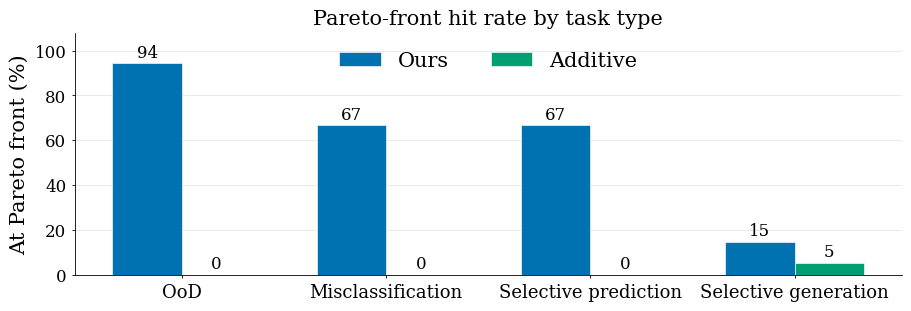

Saved plot to /home/nkotelevskii/github/multidimensional_uncertainty/resources/paper_tables/article_pareto_by_task_barplot.pdf


In [9]:
def plot_pareto_by_task_barplot(plot_df, output_path):
    if plot_df.empty:
        print("No Pareto-by-task data available; skipped plot.")
        return None

    present_tasks = [task for task in TASK_ORDER if task in set(plot_df["problem_type"].astype(str))]
    x = np.arange(len(present_tasks))
    width = 0.34

    with plt.rc_context({
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "font.size": 15,
        "axes.labelsize": 15,
        "axes.titlesize": 15,
        "legend.fontsize": 15,
        "xtick.labelsize": 13,
        "ytick.labelsize": 12,
        "axes.linewidth": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }):
        fig, ax = plt.subplots(figsize=(9, 3), constrained_layout=True)
        for method_idx, method in enumerate(METHOD_ORDER):
            values = []
            counts = []
            for task in present_tasks:
                row = plot_df[
                    plot_df["problem_type"].astype(str).eq(task)
                    & plot_df["method"].astype(str).eq(method)
                ]
                if row.empty:
                    values.append(0.0)
                    counts.append(0)
                else:
                    values.append(float(row.iloc[0]["pareto_percentage"]))
                    counts.append(int(row.iloc[0]["total_pairs"]))

            offset = (method_idx - (len(METHOD_ORDER) - 1) / 2) * width
            bars = ax.bar(
                x + offset,
                values,
                width=width,
                label=method,
                color=PALETTE[method],
                edgecolor="white",
                linewidth=0.45,
                zorder=3,
            )
            labels = [f"{value:.0f}" if count else "" for value, count in zip(values, counts)]
            ax.bar_label(bars, labels=labels, padding=1.5, fontsize=12)

        ax.set_xticks(x)
        ax.set_xticklabels([TASK_LABELS[task] for task in present_tasks])
        ax.set_ylim(0, 108)
        ax.set_ylabel("At Pareto front (%)")
        ax.set_title("Pareto-front hit rate by task type")
        ax.legend(frameon=False, loc="upper center", ncols=len(METHOD_ORDER))
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, color="0.88", linewidth=0.5)
        ax.xaxis.grid(False)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        for spine in ("left", "bottom"):
            ax.spines[spine].set_linewidth(0.6)
        ax.tick_params(axis="both", width=0.6, length=2.5)
        fig.savefig(output_path, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    return fig

plot_pareto_by_task_barplot(pareto_by_task, PARETO_BY_TASK_FIG)
print(f"Saved plot to {PARETO_BY_TASK_FIG}")
